Refer to `link` for compete data.

This notebook takes in the output of the MATLAB-generated bWSME coupling map. The coupling between self-residues (or residues in the same block) is designated as Inf, which would break other downstream algorithms. We've chosen to reolve this by replacing positive Inf values with the highest non-Inf value, and similarly with negative Inf values. The output is a coupling matrix in a .csv format that can then be used for downstream analysis.


---


This pipeline was tested and verified for the Villin protein alone. We were unable to run it for RAS due to STRIDE server outage, and for the Rhodopsin fragment due to hardware constraints.

The bWSME coupling map generation for the Rhodopsin protein was directly taken from published data (https://github.com/AthiNaganathan/GPCR-Landscapes; `CouplingMat_310_gpcr1a` from `gpcr1a.mat`) and then run through this notebook to resolve Inf issues.

In [1]:
!pip install numpy pandas --quiet

In [2]:
import numpy as np
import pandas as pd

print("Libraries loaded successfully.")

Libraries loaded successfully.


Upload your file

In [12]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for fname in uploaded.keys():
    print(f" - {fname}")

Saving RAS_couplings.csv to RAS_couplings.csv

Uploaded files:
 - RAS_couplings.csv


Enter protein name

In [13]:
pname = input("Enter protein name (without extension): ").strip()

input_file = f"{pname}_couplings.csv"
output_file = f"{pname}_bWSME_coupling.csv"

print(f"\nInput file: {input_file}")
print(f"Output file: {output_file}")

Enter protein name (without extension): Rhodopsin

Input file: Rhodopsin_couplings.csv
Output file: Rhodopsin_bWSME_coupling.csv


Modifying matrix

In [14]:
print("Loading coupling matrix...")

df = pd.read_csv(input_file, header=None)
matrix = df.values.astype(float)
print(f"Shape: {matrix.shape}")

pos_inf_count = np.isposinf(matrix).sum()
neg_inf_count = np.isneginf(matrix).sum()

print("\nInf values found:")
print(f" +Inf values: {pos_inf_count}")
print(f" -Inf values: {neg_inf_count}")

Loading coupling matrix...
Shape: (348, 348)

Inf values found:
 +Inf values: 1384
 -Inf values: 0


In [15]:
print("Replacing Inf values...")

finite_vals = matrix[np.isfinite(matrix)]
positive_vals = finite_vals[finite_vals > 0]
negative_vals = finite_vals[finite_vals < 0]

if len(positive_vals) > 0:
    max_positive = np.max(positive_vals)
else:
    max_positive = 0

if len(negative_vals) > 0:
    max_negative = np.min(negative_vals)
else:
    max_negative = 0

print(f"Max finite positive value: {max_positive}")
print(f"Most negative finite value: {max_negative}")
matrix[np.isposinf(matrix)] = max_positive
matrix[np.isneginf(matrix)] = max_negative
print("Inf values replaced.")
print(f"Remaining +Inf: {np.isposinf(matrix).sum()}")
print(f"Remaining -Inf: {np.isneginf(matrix).sum()}")

pd.DataFrame(matrix).to_csv(output_file, index=False, header=False)
print(f"\nCleaned matrix saved as: {output_file}")

Replacing Inf values...
Max finite positive value: 45.3222899592681
Most negative finite value: -25.8197561686268
Inf values replaced.
Remaining +Inf: 0
Remaining -Inf: 0

Cleaned matrix saved as: Rhodopsin_bWSME_coupling.csv


Quick Visualization

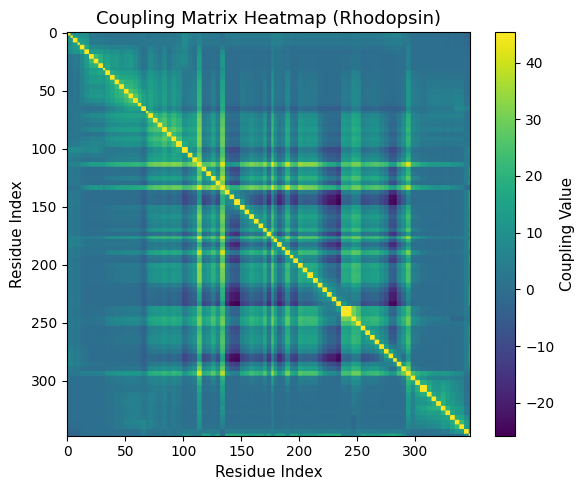

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
im = plt.imshow(matrix, cmap='viridis', aspect='auto')
cbar = plt.colorbar(im)
cbar.set_label("Coupling Value", fontsize=11)
plt.title(f"Coupling Matrix Heatmap ({pname})", fontsize=13)
plt.xlabel("Residue Index", fontsize=11)
plt.ylabel("Residue Index", fontsize=11)
plt.tight_layout()
plt.show()